In [41]:
import matplotlib.pyplot as plt

from rgfn import ReactionDataFactory
from rgfn.gfns.reaction_gfn.proxies.path_cost_proxy import PathCostProxy
from notebooks.utils.sampling_results import SamplingResult
from collections import defaultdict
from pathlib import Path

import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from notebooks.utils.training_results import TrainingResults

template_name = 'synflow_64'
task_name = 'gsk'
data_dir = Path('../../data')
threshold = 8.0 if task_name == 'seh' else 0.8
model_names = ['rgfn_old', 'synflownet', 'rgfn_is_decomposable', 'rgfn_cost_biasing', 'rgfn_expl_bias']

In [42]:
from notebooks.utils.training_results import TrainingResultsList

results_dict = {}

for model_name in tqdm(model_names):
    results_list = []
    for seed in range(3):
        try:
            result = TrainingResults(
                model_name=model_name,
                templates_name=template_name,
                seed=seed,
                task_name=task_name,
                threshold=threshold,
                results_dir=Path('../results'),
            )
            results_list.append(result)
        except FileNotFoundError:
            print(f'File not found: {model_name}, {seed}')
    results_dict[model_name] = TrainingResultsList(results_list)

  0%|          | 0/5 [00:00<?, ?it/s]

File not found: rgfn_old, 2


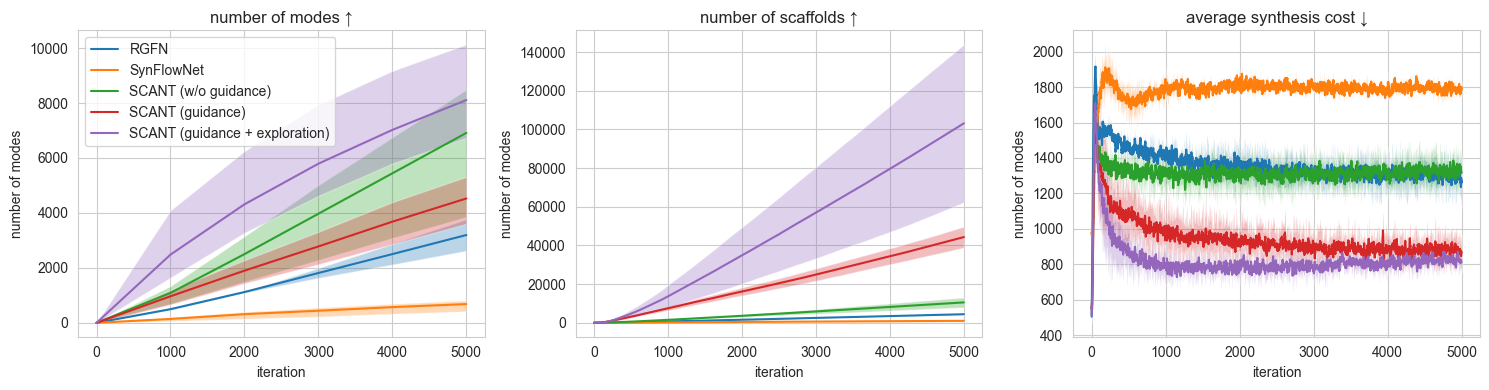

In [43]:
import numpy as np
from typing import Literal
import matplotlib.pyplot as plt
modes_every_n_iteration = 1000
n_forward_in_batch = 64

def plot_metric(results: TrainingResultsList, metric: str, max_or_std: Literal['max', 'std'] = 'std'):
    results = results.results
    max_len_results_idx = np.argmax([len(result.__getattribute__(metric)) for result in results])
    if 'modes' in metric:
        x = [i * modes_every_n_iteration for i in range(0, len(results[max_len_results_idx].num_modes) + 1)]
        y = [[0] + list(result.num_modes) for result in results]
    else:
        x = range(len(results[max_len_results_idx].num_scaffolds[::n_forward_in_batch]))
        y = [result.__getattribute__(metric)[::n_forward_in_batch] for result in results]

    if metric == 'cheapest_scaffolds_path_costs':
        x = x[1000:]
        y = [y_i[1000:] for y_i in y]

    max_len = max(len(y_i) for y_i in y)
    y = [np.pad(y_i, (0, max_len - len(y_i)), mode='edge') for y_i in y]
    y_mean = np.mean(y, axis=0)
    name = name_map.get(results[0].model_name, results[0].model_name)

    if 'disabled' in name:
        style = ':'
    elif 'uniform' in name:
        style = '--'
    elif 'count-based' in name:
        style = '-'
    # style = '-' if 'disabled' in name else '--'
    plt.plot(x, y_mean, label=name)

    if max_or_std == 'std':
        y_std = np.std(y, axis=0)
        _floor = y_mean - y_std
        _floor[_floor < 0] = 0
        plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
    elif max_or_std == 'max':
        y_min = np.min(y, axis=0)
        y_max = np.max(y, axis=0)
        plt.fill_between(x, y_min, y_max, alpha=0.3)

name_map = {
    'rgfn_old': 'RGFN',
    'synflownet': 'SynFlowNet',
    'rgfn_is_decomposable': 'SCANT (w/o guidance)',
    'rgfn_cost_biasing': 'SCANT (guidance)',
    'rgfn_expl_bias': 'SCANT (guidance + exploration)',
}

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.xlabel('iteration')
plt.ylabel('number of modes')
plt.title(u'number of modes \u2191')

for model_name, results_list in results_dict.items():
    plot_metric(results_list, 'num_modes', 'max')
plt.legend() 
plt.subplot(1, 3, 2)
plt.xlabel('iteration')
plt.ylabel('number of modes')
plt.title(u'number of scaffolds \u2191')
for model_name, results_list in results_dict.items():
    plot_metric(results_list, 'num_scaffolds', 'std')
    
plt.subplot(1, 3, 3)
plt.xlabel('iteration')
plt.ylabel('number of modes')
plt.title(u'average synthesis cost \u2193')
for model_name, results_list in results_dict.items():
    plot_metric(results_list, 'last_n_average_path_costs', 'std')

plt.tight_layout()
plt.savefig(f'outputs/main_table_learning_plots_{task_name}_{template_name}.pdf')
# plt.title(u'sEH proxy \u2193')